# Lead Scoring Model

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay,classification_report, roc_auc_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier
import shap

%matplotlib inline

In [23]:
df = pd.read_csv("../data/segmented/Segmented_Leads.csv")
df = df.set_index("Lead Number")
df.head(5)

,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,...,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Update me on Supply Chain Content,Get updates on DM Content,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Cluster
Lead Number,,,,,,,,,,,,,,,,,,,,,
660737,API,Olark Chat,No,No,0,0.0,0,0.0,Page Visited on Website,Unknown,...,No,No,No,No,Interested in other courses,No,No,No,No,Passive Chat Inquiries
660728,API,Organic Search,No,No,0,5.0,674,2.5,Email Opened,India,...,No,No,No,No,Ringing,No,No,No,No,Normal Traffic
660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,Email Opened,India,...,No,No,No,No,Will revert after reading the email,No,No,No,Yes,Normal Traffic
660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,Other,India,...,No,No,No,No,Ringing,No,No,No,No,Normal Traffic
660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,Converted to Lead,India,...,No,No,No,No,Will revert after reading the email,No,No,No,No,Normal Traffic


**Separated the independent and dependent fields**

In [24]:
y = df["Converted"]
X_val = df.drop(columns="Converted")

**Encoding the X values as Random Forest or Logistic Regression require numeric input**

In [25]:
X_encoded = pd.get_dummies(data=X_val,drop_first=True) #Drop first reduces one extra column generation for each column
X_encoded.head()

,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,...,Tags_Interested in other courses,Tags_Other,Tags_Ringing,Tags_Unknown,Tags_Will revert after reading the email,A free copy of Mastering The Interview_Yes,Cluster_Marketing Niche Professionals,Cluster_Normal Traffic,Cluster_Passive Chat Inquiries,Cluster_Window Shoppers
Lead Number,,,,,,,,,,,,,,,,,,,,,
660737,0.0,0,0.0,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,True,False
660728,5.0,674,2.5,False,False,False,False,False,False,True,...,False,False,True,False,False,False,False,True,False,False
660727,2.0,1532,2.0,True,False,False,False,False,False,False,...,False,False,False,False,True,True,False,True,False,False
660719,1.0,305,1.0,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,True,False,False
660681,2.0,1428,1.0,True,False,False,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded,y,test_size=0.2,random_state=42)

In [27]:
X_encoded.select_dtypes(include=["number","int"]).nunique()

TotalVisits                      41
Total Time Spent on Website    1731
Page Views Per Visit            114
dtype: int64

In [28]:
X_encoded.select_dtypes("float").columns

Index(['TotalVisits', 'Page Views Per Visit'], dtype='str')

**Standardized the values to put all features on the same scale**

In [29]:
cont_cols = X_encoded.select_dtypes("number").columns # chose "number" type as preciously we saw all the columns we want are already number type
scalar = StandardScaler()
X_train[cont_cols] = scalar.fit_transform(X_train[cont_cols])
X_test[cont_cols] = scalar.transform(X_test[cont_cols])

### Logistic Regression

In [30]:
lr = LogisticRegression(random_state=42,max_iter=1000).fit(X_train,y_train) #1000 max iter allows more attempts on finding the best fit
predict_lr = lr.predict(X_test)

**Logistic Regression Results**

The results below from classification report, confusion matrix and ROC-AUC show that
- Logistic regression has a 91% correct positive prediction (Precision), 94% actual positive values predicted (Recall) and an accuracy of 91%.
- 644 converted leads were correctly predicted with 97 converted leads predicted as dead lead.
- The model achieved a 96% Reciever Operating Characteristic-Area Under Curve (ROC-AUC) which is the overall ability to correctly distinguish between positive and negative classes.

As a result a basic model like logistic regression performed really for for our dataset.

In [31]:
print(classification_report(y_test,predict_lr))

              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1107
           1       0.91      0.87      0.89       741

    accuracy                           0.91      1848
   macro avg       0.91      0.90      0.91      1848
weighted avg       0.91      0.91      0.91      1848



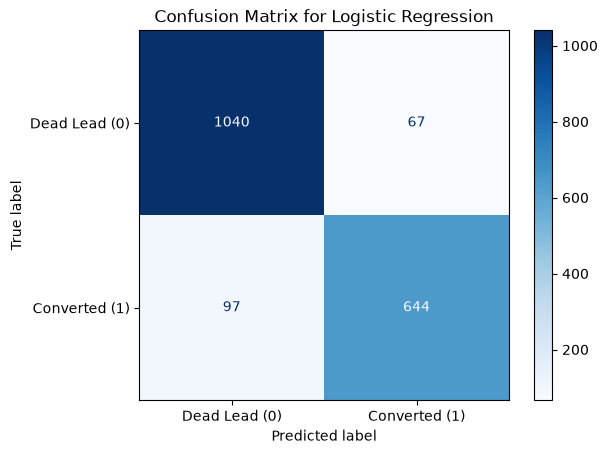

In [32]:
ConfusionMatrixDisplay.from_predictions(y_test,predict_lr,cmap="Blues",display_labels=["Dead Lead (0)","Converted (1)"])
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

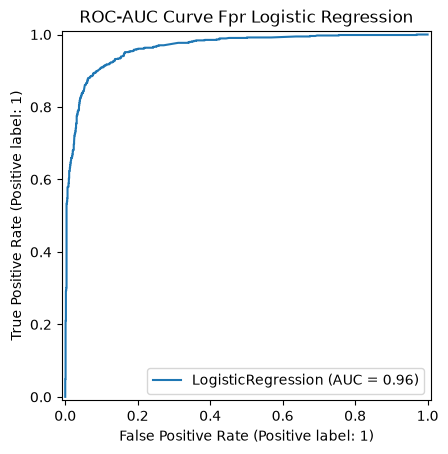

In [33]:
converted_prob_lr = lr.predict_proba(X_test)[:,1]

lr_score = roc_auc_score(y_test,converted_prob_lr)

RocCurveDisplay.from_estimator(lr,X_test,y_test)
plt.title("ROC-AUC Curve Fpr Logistic Regression")
plt.show()

*If you want to focus on the main results only, skip to "Tuned Random Forest Classifier"*

### Random Forest Classifier

**Random Forest Results**

The results below from classification report, confusion matrix and ROC-AUC show that
- Random Forest did not significantly do better than Logistic Regression as it only increased the precision by 1 percent (92%)
- But investigating the training accuracy revealed that the model was overfitting with a training accuracy of 98.7% and a testing accuracy of 91.2% 

As a result Random forest needs parameter tuning so it does not overfit and allow us to compare the results with Logistic Regression model.

In [34]:
rf = RandomForestClassifier(n_estimators=100,random_state=42).fit(X_train,y_train)
predict_rf = rf.predict(X_test)
converted_prob_rf = rf.predict_proba(X_test)[:,1]

In [35]:
print(classification_report(y_test,predict_rf))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1107
           1       0.90      0.87      0.89       741

    accuracy                           0.91      1848
   macro avg       0.91      0.91      0.91      1848
weighted avg       0.91      0.91      0.91      1848



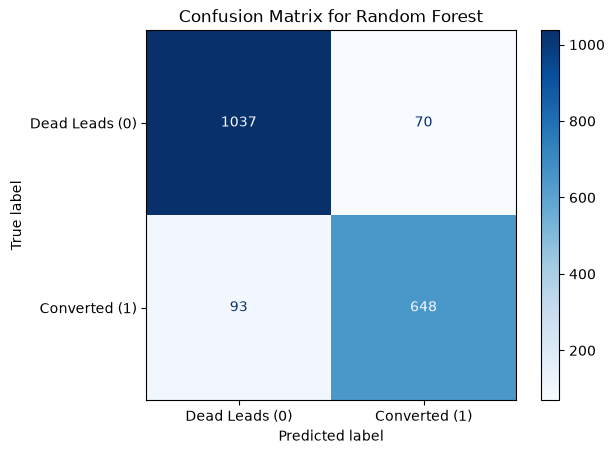

In [36]:
ConfusionMatrixDisplay.from_predictions(y_test,predict_rf,cmap="Blues",display_labels=["Dead Leads (0)","Converted (1)"])
plt.title("Confusion Matrix for Random Forest")
plt.show()

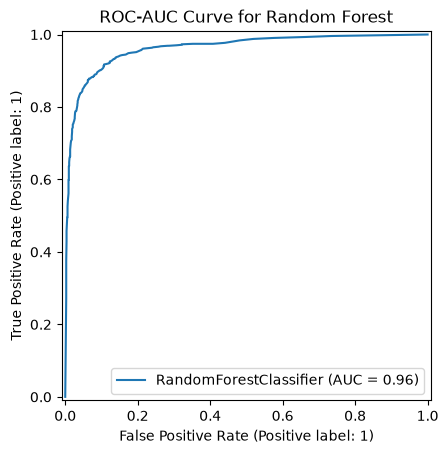

In [37]:
rf_score = roc_auc_score(y_test,converted_prob_rf)

RocCurveDisplay.from_estimator(rf,X_test,y_test)
plt.title("ROC-AUC Curve for Random Forest")
plt.show()

**Checking if the model overfitted**

In [38]:
print(f"Training Accuracy: {rf.score(X_train, y_train):.3f}")
print(f"Testing Accuracy: {rf.score(X_test, y_test):.3f}")

Training Accuracy: 0.987
Testing Accuracy: 0.912


### Tuned Random Forest Classifier

- Tuned maximum depth to restrict tree's height
- Tuned minimum sample split to set a minimum number of data points to split branch restricting model to creat complex rules just to separate few data points
- Tuned minimum sample leaf ensuring the the model creates rules that apply to general population rather than individuals

In [39]:
params = {
    "max_depth":[5,10,15,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf": [1,2,4]
}

**Used Grid Search to test every single combination of the custom parameters to find best performing model**

In [40]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=params,cv=5,scoring="roc_auc",n_jobs=-1)
rf_tuned = grid_search.fit(X_train,y_train)
predict_rf_tuned = rf_tuned.predict(X_test)
converted_prob_rf_tuned = rf_tuned.predict_proba(X_test)[:,1]
print(grid_search.best_params_)

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}


**Tuned Random Forest Results**

The results below from classification report, confusion matrix and ROC-AUC show that
- This model increased the precision (92%) and accuracy (92%) by 1 percent compared to our baseline logistic regression model.
- The model achieved a 99% ROC-AUC beating the baseline value of 96%.

As a result a The tuned random forest classifier is working better than the baseline logistic regression model.

*If you missed any definition, please check the results from logistic regression model*

In [41]:
print(classification_report(y_test,predict_rf_tuned))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      1107
           1       0.91      0.88      0.89       741

    accuracy                           0.92      1848
   macro avg       0.92      0.91      0.91      1848
weighted avg       0.92      0.92      0.92      1848



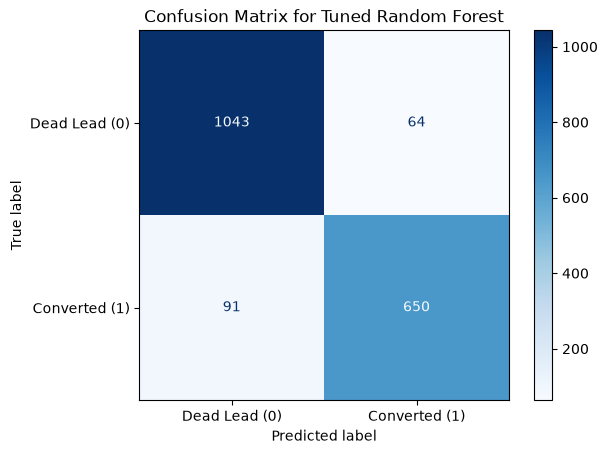

In [42]:
ConfusionMatrixDisplay.from_predictions(y_test,predict_rf_tuned,display_labels=["Dead Lead (0)","Converted (1)"],cmap="Blues")
plt.title("Confusion Matrix for Tuned Random Forest")
plt.show()

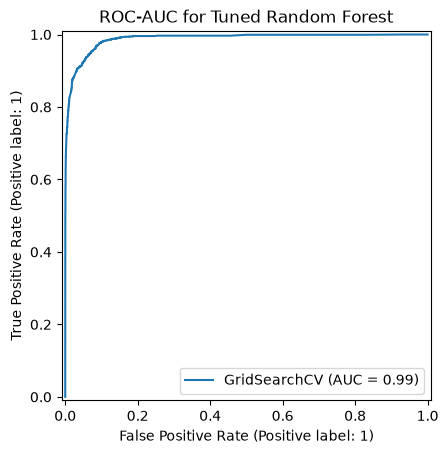

In [47]:
rf_tuned_score = roc_auc_score(y_test,converted_prob_rf_tuned)

RocCurveDisplay.from_estimator(rf_tuned,X_train,y_train)
plt.title("ROC-AUC for Tuned Random Forest")
plt.show()

**Using SHAP to check Feature Importance**

The graph below suggests that
- "will revert after reading the email" tag is the biggest positive predictor
- higher time on website and having "sms sent" as last activity makes them highly likely to convert
- "ringing" tag is the worst red flag, heavily predicting failure. "interested in other courses" also hurts the score
- "working professional" occupation and "lead add form" sources are strong positive drivers
- "unknown" data like missing occupations usually drops the score a bit

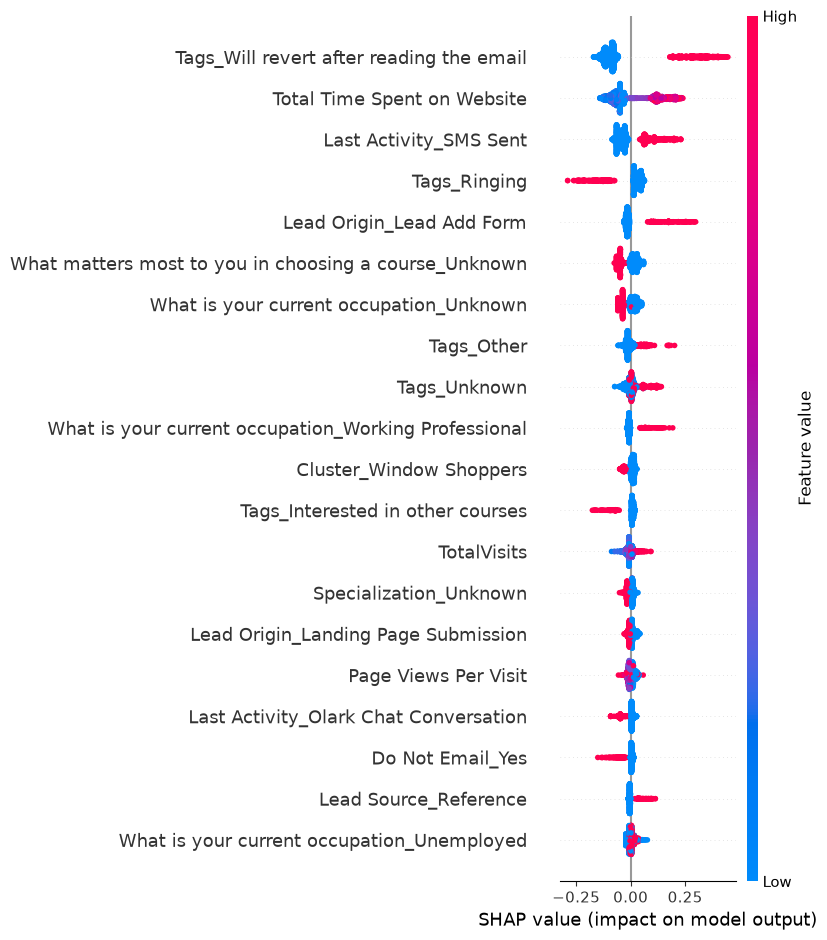

In [44]:
explainer = shap.TreeExplainer(grid_search.best_estimator_)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[:,:,1],X_test)

**Added lead scores to the dataset**

*Converted Prediction Probability to a score from 1-100 suggesting which customers to priotize for maximum lead conversion*

In [45]:
lead_scores = (converted_prob_rf_tuned*100).astype("int")

df_final =X_test.copy()

df_final["Lead Score"] = lead_scores

df_final = df_final.sort_values(by="Lead Score",ascending=False)
df_final.head(10)

,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Google,Lead Source_Olark Chat,Lead Source_Organic Search,...,Tags_Other,Tags_Ringing,Tags_Unknown,Tags_Will revert after reading the email,A free copy of Mastering The Interview_Yes,Cluster_Marketing Niche Professionals,Cluster_Normal Traffic,Cluster_Passive Chat Inquiries,Cluster_Window Shoppers,Lead Score
Lead Number,,,,,,,,,,,,,,,,,,,,,
608022,0.106264,1.476644,0.749824,True,False,False,False,False,False,False,...,False,False,False,True,True,False,True,False,False,100
643897,-0.703744,-0.889097,-1.092667,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,99
643832,-0.703744,-0.889097,-1.092667,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,99
581759,1.321277,1.587652,0.058890,True,False,False,False,False,False,True,...,False,False,False,True,True,False,True,False,False,99
600391,-0.298740,1.769632,-0.171422,False,False,False,False,True,False,False,...,False,False,False,True,False,False,True,False,False,99
633962,-0.703744,-0.889097,-1.092667,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,99
606653,0.106264,0.750544,0.749824,True,False,False,False,False,False,False,...,False,False,False,True,True,False,True,False,False,99
624434,-0.703744,-0.889097,-1.092667,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,99
626300,0.308766,1.016235,1.210446,True,False,False,False,False,False,False,...,False,False,False,True,True,False,True,False,False,99


In [46]:
df_final.to_csv("../data/final/Final_Leads.csv",index=False)